<a href="https://colab.research.google.com/github/harpreet4555/House-Price-Prediction-/blob/main/HOUSE_PRICE_USA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## **OBJECTIVE OF HOUSE PRICE PREDICTION MODEL:**

House price prediction models assist buyers, sellers, investors, and real estate professionals in making more informed decisions regarding purchasing, pricing, and investment strategies.

     • Predict house prices in USA using AI.
     • Understand which features influence housing prices the most.

## **Import some Libraries For House Price Prediction Model**

***1.Data Handling:***

import pandas as pd  
                                                                     
import numpy as np                                                                                                                                                                                                              
 ***2.Data Visualization***
              
  import matplotlib.pyplot as plt                                                                            
  import seaborn as sns                                                                  
 ***3. Preprocessing & Encoding***
  
  
  from sklearn.model_selection import train_test_split
  
from sklearn.model_selection import cross_val_score   
  from sklearn.preprocessing import LabelEncoder        
  from category_encoders import MEstimateEncoder    
***4.Linear Regression***
  
  from sklearn.linear_model import LinearRegression     

***5. Model Evaluation***
   
   
   from sklearn.metrics import r2_score



In [11]:
#Libraries contain ready-made functions and classes written by others, so you don’t need to write everything from scratch


import numpy as np   # for reading and handling data
import pandas as pd  # for reading and handling data



import seaborn as sns     # for advanced data visualization
import matplotlib.pyplot as plt    # for plotting graphs
import plotly.express as px        #used to create interactive plots like pie,bar etc.

from sklearn.metrics import  r2_score     # model performance
from sklearn.preprocessing import LabelEncoder   #Converts categorical text data into numbers.
from sklearn.model_selection import cross_val_score   #Checks model accuracy using cross-validation.
from sklearn.model_selection import train_test_split  # Splits data into training and testing sets.
from sklearn.linear_model import LinearRegression     # machine learning model
from sklearn.ensemble import RandomForestRegressor
!pip install category_encoders
from category_encoders import MEstimateEncoder   #Converts categorical text data into numbers.



# **DataSet Collecting From Kaggle**

In [12]:
df=pd.read_csv('/content/Project data.csv')

# **Displaying the Dataset**

In [13]:
df

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,2014-07-09 00:00:00,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1954,1979,501 N 143rd St,Seattle,WA 98133,USA
4596,2014-07-09 00:00:00,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,1983,2009,14855 SE 10th Pl,Bellevue,WA 98007,USA
4597,2014-07-09 00:00:00,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,2009,0,759 Ilwaco Pl NE,Renton,WA 98059,USA
4598,2014-07-10 00:00:00,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,1974,0,5148 S Creston St,Seattle,WA 98178,USA


# **what is House price pridiction?**

House Price Prediction in Python is a machine learning project where the goal is to build a model that can predict the price of a house based on some features .

## **Displaying The Size Of dataframe**

In [14]:
#df.shape is an attribute of a DataFrame object that returns a tuple representing the dimensionality of the DataFrame.
df.shape

(4600, 18)

## **Summary Of The Dataframe**

In [15]:
#The df.info() method in the Pandas library in Python provides a concise summary of a DataFrame.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

# **List  All Column Names**

In [16]:
#df.columns is an attribute of a DataFrame object that returns the column labels of the DataFrame
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='object')

## **Count Of Unique Values In A Column.**

In [17]:
# value count is used to count the number of occurrences of each unique value in a pandas Series or DataFrame column.
df.street.value_counts()

,count
street,
2520 Mulberry Walk NE,4
2500 Mulberry Walk NE,3
2803 SW Bataan St,2
8354 11th Ave NW,2
6008 8th Ave NE,2
...,...
25919 SE 37th Way,1
14435 SE 263rd St,1
2150 N 128th St,1


In [18]:
# value count method is used to count the number of occurrences of each unique value in a pandas Series or DataFrame column.
df.city.value_counts()

,count
city,
Seattle,1573
Renton,293
Bellevue,286
Redmond,235
Kirkland,187
Issaquah,187
Kent,185
Auburn,176
Sammamish,175


In [19]:
df.condition.value_counts() #condition column is based on the ratings of houses.

,count
condition,
3,2875
4,1252
5,435
2,32
1,6


In [20]:
# count the number of occurrences of each unique value in a pandas Series or DataFrame column.
df.country.value_counts()

,count
country,
USA,4600


In [21]:
# count the number of occurrences of each unique value in a pandas Series or DataFrame column.
df.statezip.value_counts()

,count
statezip,
WA 98103,148
WA 98052,135
WA 98117,132
WA 98115,130
WA 98006,110
...,...
WA 98047,6
WA 98288,3
WA 98050,2


In [22]:
# count the number of occurrences of each unique value in a pandas Series or DataFrame column.
df.waterfront.value_counts()

,count
waterfront,
0,4567
1,33


## **statistical summary of all numerical columns**

In [23]:
#It provides a statistics  summary of a DataFrame of numerical columns.
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


## **Count The Total No. Of  Duplicate Rows In Dataframe**

In [24]:
#df.duplicated().sum() in pandas is used to efficiently count the total number of duplicate rows in a DataFrame
df.duplicated().sum()

np.int64(0)

## **Creates a bar chart showing how many houses are in each city.**

<Axes: xlabel='city'>

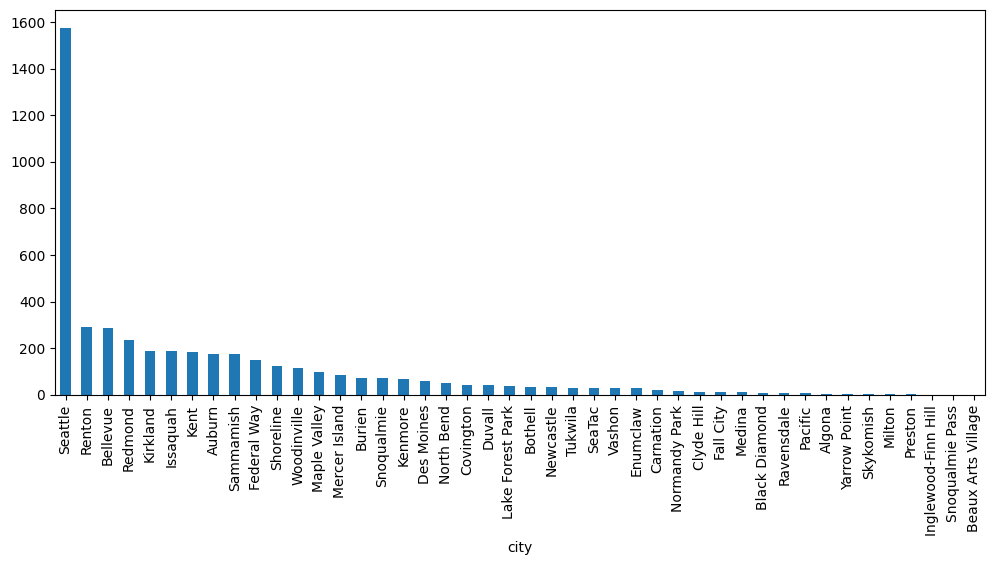

In [25]:
#This command creates a bar plot showing the number of occurrences (i.e., frequency) of each unique city in the city column of the DataFrame df.
df.city.value_counts().plot(kind='bar', figsize=(12,5))

# **Creates a bar chart of the average house price per city**

**"aggregation function" — it tells how to combine values**

***cross-tabulation***or contingency table helpful for summarizing the relationship between two colums or  variables.

<Axes: xlabel='city'>

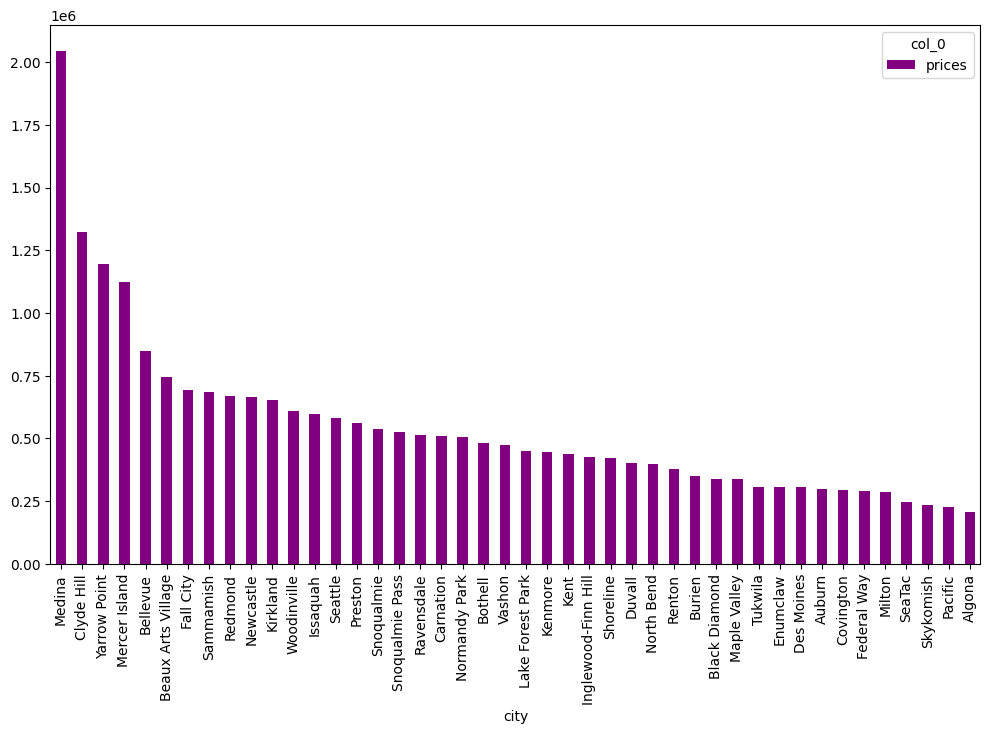

In [26]:
# calculate the average price per city
pd.crosstab(index = df.city , columns = "prices" , values = df.price , aggfunc = "mean").sort_values(ascending  = False , by = "prices").plot(kind = "bar" , figsize = (12,7) , color = "purple")

## **Creates a bar chart showing how many houses have same condition rating.**

<Axes: xlabel='condition'>

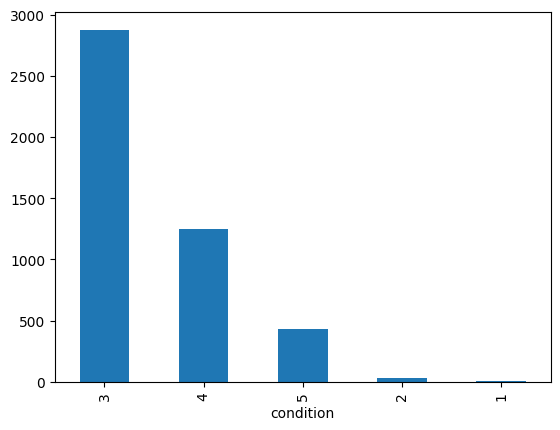

In [27]:
#This line creates a bar chart showing how many houses exist in each condition category (e.g., Poor to Excellent).
df.condition.value_counts().plot(kind="bar")

# **Creates a pie chart of the first 5 house prices.**


### px.pie(...) → Plots them as a pie chart

In [28]:
#top five  house prices in dataframe.
top_5_prices = df['price'].head(5)
fig = px.pie(values=top_5_prices, names=top_5_prices.index, title="Top 5 Prices")
fig.show()

# **Creates a pie chart using Matplotlib to show the top 5 house prices**

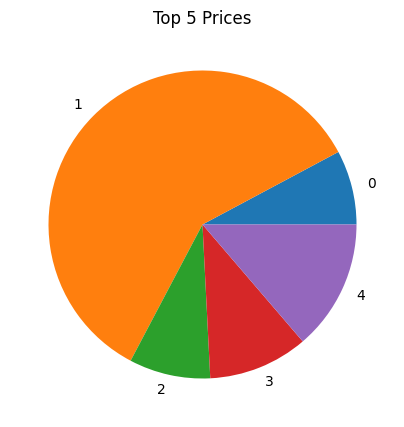

In [29]:
#this method is used to visualize the distribution of the top 5 house prices
names = top_5_prices.index
plt.figure(figsize=(5,5 ))
plt.pie(top_5_prices, labels=names)
plt.title("Top 5 Prices")
plt.show()

# **Creates a scatter plot showing how house price changes with number of bedrooms.**

scatter(...) → plots each house as a dot

alpha=0.5 → adds transparency

Helps visualize the correlation between bedrooms and price

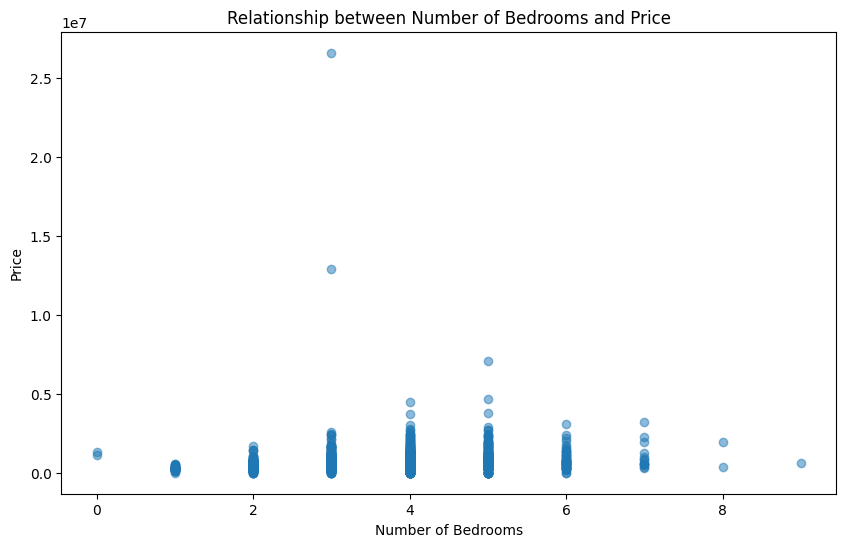

In [30]:
#A scatter plot of how house price varies with number of bedrooms.
#Each dot = one house.
plt.figure(figsize=(10, 6))
plt.scatter(df['bedrooms'], df['price'], alpha=0.5)
plt.xlabel('Number of Bedrooms')
plt.ylabel('Price')
plt.title('Relationship between Number of Bedrooms and Price')
plt.show()

# **Displays the first row of the DataFrame.**

In [31]:
df.head(1)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.5,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA


# **Calculates correlation between price and selected numerical features.**

# Correlation :

Correlation tells us how strongly two variables are related.

.corr() shows how strongly each feature is related to price

Values range from -1 to 1

    🔹 1 = strong positive

    🔹 -1 = strong negative

    🔹 0 = no relation

In [32]:
#used to compute the correlation matrix between selected numerical columns in your DataFrame.
df[['price','bedrooms','bathrooms','sqft_living','sqft_lot','floors','waterfront','view','condition','sqft_above','sqft_basement','yr_built','yr_renovated']].corr()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
price,1.000000,0.200336,0.327110,0.430410,0.050451,0.151461,0.135648,0.228504,0.034915,0.367570,0.210427,0.021857,-0.028774
bedrooms,0.200336,1.000000,0.545920,0.594884,0.068819,0.177895,-0.003483,0.111028,0.025080,0.484705,0.334165,0.142461,-0.061082
bathrooms,0.327110,0.545920,1.000000,0.761154,0.107837,0.486428,0.076232,0.211960,-0.119994,0.689918,0.298020,0.463498,-0.215886
sqft_living,0.430410,0.594884,0.761154,1.000000,0.210538,0.344850,0.117616,0.311009,-0.062826,0.876443,0.447206,0.287775,-0.122817
sqft_lot,0.050451,0.068819,0.107837,0.210538,1.000000,0.003750,0.017241,0.073907,0.000558,0.216455,0.034842,0.050706,-0.022730
floors,0.151461,0.177895,0.486428,0.344850,0.003750,1.000000,0.022024,0.031211,-0.275013,0.522814,-0.255510,0.467481,-0.233996
waterfront,0.135648,-0.003483,0.076232,0.117616,0.017241,0.022024,1.000000,0.360935,0.000352,0.078911,0.097501,-0.023563,0.008625
view,0.228504,0.111028,0.211960,0.311009,0.073907,0.031211,0.360935,1.000000,0.063077,0.174327,0.321602,-0.064465,0.022967
condition,0.034915,0.025080,-0.119994,-0.062826,0.000558,-0.275013,0.000352,0.063077,1.000000,-0.178196,0.200632,-0.399698,-0.186818
sqft_above,0.367570,0.484705,0.689918,0.876443,0.216455,0.522814,0.078911,0.174327,-0.178196,1.000000,-0.038723,0.408535,-0.160426


# **Creates a heatmap showing correlation between all numeric features.**

.corr() → Calculates correlation

heatmap → Visualizes it with colors

annot=True → Shows numbers on the heatmap

# **Heatmap:**

A heatmap is a colored chart that shows the relationship (correlation) between multiple numeric features in a dataset.

# **Why Use a Heatmap?**

    Makes it easy to visualize correlations

    Darker or brighter colors show stronger relationships



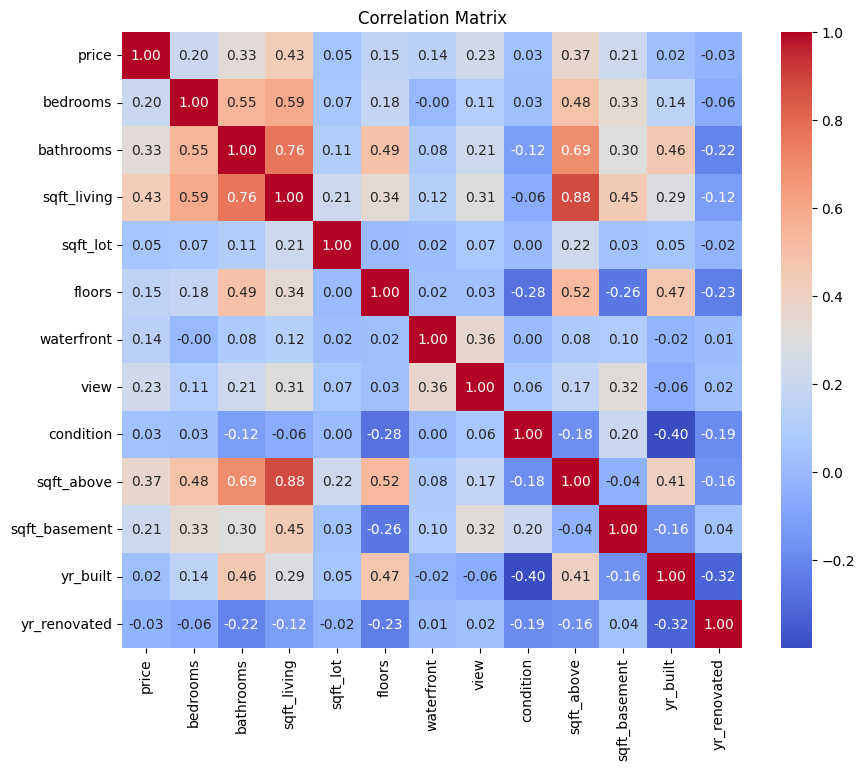

In [33]:
#It  is a complete pipeline to automatically calculate and visualize the correlation between all numeric features in your dataset using a heatmap.
numeric_columns = df.select_dtypes(include=['float64', 'int64'])

correlation_matrix = numeric_columns.corr()#(.corr() to compute pairwise correlation between all of them)
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")#(annot=True: Shows the numbers on the heatmap,cmap='coolwarm': Red-blue color scheme,fmt=".2f": Formats numbers to 2 decimal places)
plt.title('Correlation Matrix')
plt.show()

# **Adds a new column age in dataframe showing how old each house is.**

In [34]:
# Calculates the age of the house at the time it was listed/sold.
df['date'] = pd.to_datetime(df['date'])
df['age'] = df['date'].dt.year - df['yr_built']
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country,age
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA,59
1,2014-05-02,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA,93
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA,48
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA,51
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA,38


# **Removes columns from dataframe**

In [35]:
#This method is used for removing  column  from the DataFrame.
df= df.drop(['date','yr_built','country'], axis=1) #(axis=1=meaning columns)
df



,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_renovated,street,city,statezip,age
0,3.130000e+05,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,2005,18810 Densmore Ave N,Shoreline,WA 98133,59
1,2.384000e+06,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,0,709 W Blaine St,Seattle,WA 98119,93
2,3.420000e+05,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,0,26206-26214 143rd Ave SE,Kent,WA 98042,48
3,4.200000e+05,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,0,857 170th Pl NE,Bellevue,WA 98008,51
4,5.500000e+05,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1992,9105 170th Ave NE,Redmond,WA 98052,38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,3.081667e+05,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1979,501 N 143rd St,Seattle,WA 98133,60
4596,5.343333e+05,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,2009,14855 SE 10th Pl,Bellevue,WA 98007,31
4597,4.169042e+05,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,0,759 Ilwaco Pl NE,Renton,WA 98059,5
4598,2.034000e+05,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,0,5148 S Creston St,Seattle,WA 98178,40


In [36]:
#this is used to remove price column from X .
X= df.drop('price', axis= 'columns')



In [37]:
X

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_renovated,street,city,statezip,age
0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,2005,18810 Densmore Ave N,Shoreline,WA 98133,59
1,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,0,709 W Blaine St,Seattle,WA 98119,93
2,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,0,26206-26214 143rd Ave SE,Kent,WA 98042,48
3,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,0,857 170th Pl NE,Bellevue,WA 98008,51
4,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1992,9105 170th Ave NE,Redmond,WA 98052,38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1979,501 N 143rd St,Seattle,WA 98133,60
4596,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,2009,14855 SE 10th Pl,Bellevue,WA 98007,31
4597,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,0,759 Ilwaco Pl NE,Renton,WA 98059,5
4598,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,0,5148 S Creston St,Seattle,WA 98178,40


In [38]:
#this is used to print price column in y.
y=df.price

In [39]:
y

,price
0,3.130000e+05
1,2.384000e+06
2,3.420000e+05
3,4.200000e+05
4,5.500000e+05
...,...
4595,3.081667e+05
4596,5.343333e+05
4597,4.169042e+05
4598,2.034000e+05


# **Encodes categorical columns into numbers using smoothed target mean.**

m=0.5 → controls smoothing

fit →    
    
    Looks at the relationship between X_train and y_train

    Learns patterns, trends, or formulas.

    Stores what it learned inside the model

transform → replaces text with numeric values

## **MEstimateEncoder:**

MEstimateEncoder is used to convert categorical columns into numbers based on the target's mean value, with smoothing.

## **Why We Use MEstimateEncoder**

It helps:

    Handle rare categories better

    Avoid overfitting

    Improve model accuracy

## **What is Overfitting? **

Example:

    Model gets 100% accuracy on training data ✅

    But only 60% on test data ❌


In [40]:
#This method is used to convert on categorical data into numerical.
encoder = MEstimateEncoder(cols=['street','statezip','city'], m=0.5) #(m=0.5 controls how much smoothing is applied.)

X = encoder.fit_transform(X, y)#(fit is used to learn relationship between categorial values and target value y, transform is used to replace categorial values into numerical encodings.)

## **X refers to the input features — the data we give to the model to make predictions**

In [41]:
X

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_renovated,street,city,statezip,age
0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,2005,3.926543e+05,420925.038640,375382.589956,59
1,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,0,1.773321e+06,579828.609806,910780.097527,93
2,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,0,4.119877e+05,439795.599753,321396.799516,48
3,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,0,4.639877e+05,846665.448904,602458.148401,51
4,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1992,5.506543e+05,667403.915787,637239.879032,38
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4595,3.0,1.75,1510,6360,1.0,0,0,4,1510,0,1979,3.894321e+05,579828.609806,375382.589956,60
4596,3.0,2.50,1460,7573,2.0,0,0,3,1460,0,2009,5.402099e+05,846665.448904,638000.375382,31
4597,3.0,2.50,3010,7014,2.0,0,0,3,3010,0,0,4.619238e+05,377338.959552,499702.282870,5
4598,4.0,2.00,2090,6630,1.0,0,0,3,1070,1020,0,3.195877e+05,579828.609806,266822.058806,40


## **y is the target/output — the value we want the model to predict.**

In [42]:
y

,price
0,3.130000e+05
1,2.384000e+06
2,3.420000e+05
3,4.200000e+05
4,5.500000e+05
...,...
4595,3.081667e+05
4596,5.343333e+05
4597,4.169042e+05
4598,2.034000e+05


#***To split the dataframe into two parts :***
1.Training part(X_train,y_train)

2.Testing part(X_test,y_test)

In [43]:
#spilliting the data into two parts:training and testing the model.
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2 ,random_state=42 ,shuffle=True)#(shuffle =true means before spliitting data is sufflled so no bias[error] oocured)

# X_train:Features (input) used to train model






In [44]:
X_train

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_renovated,street,city,statezip,age
1898,4.0,2.50,2770,45514,2.0,0,0,4,2770,0,0,640654.329491,609315.662288,646258.457033,25
1370,4.0,3.00,3720,29043,2.0,0,0,3,3720,0,0,755320.996158,651317.936966,814931.117254,23
3038,4.0,2.50,2810,11120,2.0,0,0,3,2810,0,0,633987.662824,686533.097507,612994.154579,32
2361,4.0,3.75,4030,10800,2.0,0,0,3,4030,0,0,954392.597695,651317.936966,814931.117254,8
156,3.0,2.00,2000,7000,2.0,0,0,3,2000,0,1986,557987.662824,579828.609806,522868.056422,98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4426,3.0,1.00,1180,5002,1.5,0,0,3,1180,0,0,372326.922084,420925.038640,380163.144317,68
466,4.0,2.00,2520,6000,1.0,0,0,3,1400,1120,2007,767320.996158,579828.609806,578573.162539,93
3092,3.0,1.00,1150,8145,1.0,0,0,4,990,160,1958,377320.996158,420925.038640,380163.144317,82
3772,2.0,1.00,910,2002,1.5,0,0,3,910,0,2005,583987.662824,579828.609806,998368.812867,114


# y_train:Target (output) used to train model.


In [45]:
y_train

,price
1898,6.850000e+05
1370,8.570000e+05
3038,6.750000e+05
2361,1.485000e+06
156,5.610000e+05
...,...
4426,2.825089e+05
466,8.750000e+05
3092,2.900000e+05
3772,6.000000e+05


# X_test:Features used to test model


In [46]:
X_test

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_renovated,street,city,statezip,age
3683,3.0,2.50,1460,1613,2.0,0,0,3,1180,280,0,5.466543e+05,579828.609806,5.638597e+05,7
4411,5.0,2.25,2000,7900,1.0,0,0,4,1300,700,0,1.839877e+05,250488.457432,2.681600e+05,28
2584,3.0,3.25,2940,5432,3.0,0,3,4,2440,500,2000,1.325654e+06,579828.609806,1.041684e+06,36
69,3.0,2.50,2200,7350,1.0,0,0,5,1570,630,0,4.273210e+05,377338.959552,3.489970e+05,26
1844,3.0,2.50,1720,8755,1.0,0,0,3,1000,720,2009,3.673210e+05,290770.112355,2.886920e+05,31
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1612,3.0,1.75,1700,8400,1.0,0,0,3,1460,240,2012,6.839877e+05,579828.609806,9.403032e+05,67
1068,5.0,2.00,1930,6120,1.5,0,0,3,1930,0,1969,3.373210e+05,579828.609806,3.622913e+05,73
4350,3.0,2.00,1180,7793,1.0,0,0,4,1180,0,0,1.791065e+07,439795.599753,6.816311e+05,22
3027,4.0,2.50,2370,10083,2.0,0,0,5,2370,0,0,6.419877e+05,651317.936966,8.149311e+05,48


# y_test:Actual values used to check accuracy

In [47]:
y_test

,price
3683,544000.0
4411,0.0
2584,1712500.0
69,365000.0
1844,275000.0
...,...
1612,750000.0
1068,230000.0
4350,26590000.0
3027,687000.0


### ***Linear Regression***:Linear Regression is a model that finds the best straight-line relationship between your input features (X) and the target variable (price y).

## **Ready The Model For Predictions**

### **What is .fit() Used For?**

.fit() is the method that tells the model to learn from the data

.fit() is used to train a model in machine learning.

During .fit(), the model:

    Calculates the best line (or pattern) that fits the training data

    Stores learned parameters in Linear model.

In [48]:
# It finds the best-fit line (or plane in multiple dimensions) that minimizes prediction error.
model_lr= LinearRegression() #create a empty linear regression model.
model_lr.fit(X_train,y_train) # on training data  learn the relationship between (X,y) we use fit function.

LinearRegression()

## **Model Accuracy on Training Data**
# .score() Function:

The .score() function in scikit-learn measures how well the model performs.

Returns the R² score (coefficient of determination):
R² (R-squared) measures how well your regression model fits the data.

    1.0 = perfect prediction

    0.0 = no better than average

    < 0 = poor fit

In [49]:
#It is used to evaluate how well trained model performs.
model_lr.score(X_train,y_train)

0.9823575102329297

## **evaluate model performance after training.**

In [50]:
#how well your trained Linear Regression model performs on unseen (test) data.
model_lr.score(X_test,y_test)

0.9991010711118448

## **Scatter plot shows how close the predicted prices are to the actual prices**



Most points are clustered in the bottom-left corner, meaning:

Most house prices (actual & predicted) are in the lower price range.

A few points are far from the cluster, especially near:

(15,000,000) and (25,000,000) → these are very expensive houses
These are called outliers.

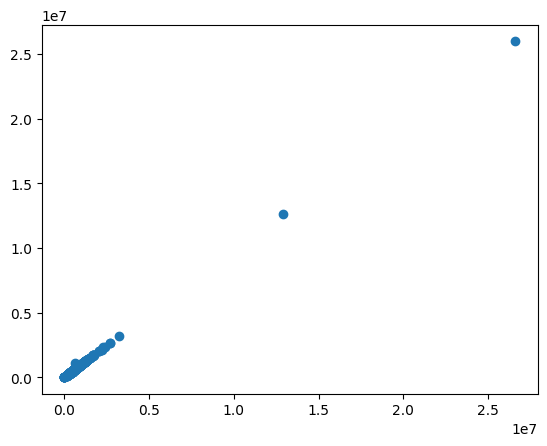

In [51]:
#visualizes how well your model's predictions match the actual house prices.
predictions = model_lr.predict(X_test)#The model uses the test features (X_test) to predict house prices
plt.scatter(y_test, predictions)


# **compares actual and predicted house prices:**

Draws a dashed black diagonal line, which means:

Perfect predictions = dot lies exactly on this line

Closer the dot is to this line → better the prediction

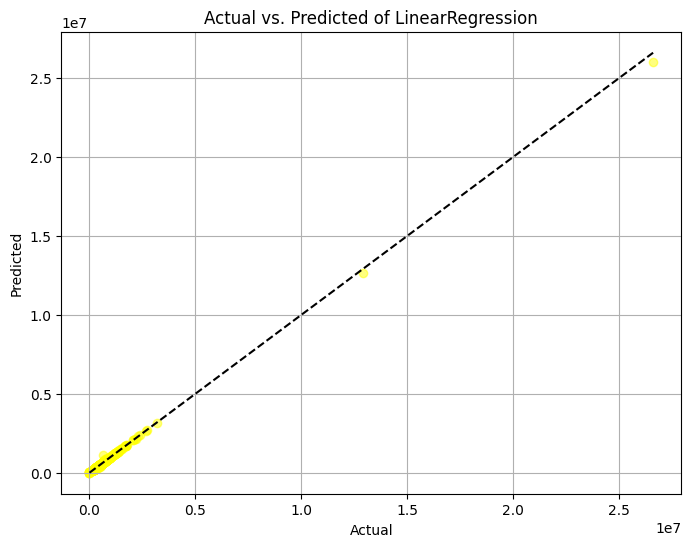

In [52]:
# shows how close your predictions are to the real value.
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, color='yellow', alpha=0.5)#alpha=0.5 makes the dots semi-transparent
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='black', linestyle='--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs. Predicted of LinearRegression')
plt.grid(True)
plt.show()

## **Check Model performance is how good .**

**Cross-validation** is a technique used to check how well your machine learning model will perform on new, unseen data.
## **What is Cross-Validation?**

Instead of training and testing the model once, it does this:

Split the training data into 10 parts (folds)

Train on 9 parts and test on the 1 remaining part

Repeat this 10 times (each time using a different part for testing)

## **Why We Check Cross-Validation?**

Get a More Reliable Accuracy.



In [53]:
#model performance is how good .
cvs = cross_val_score(model_lr, X_train, y_train, cv=10, n_jobs=-1)#This function does the cross-validation. It:Splits your training data into cv=10 equal parts (folds)Trains the model on 9 parts and tests it on the remaining 1 partRepeats this process 10 times, changing the test part each time,Gives you 10 scores (1 for each fold).
print('Accuracy: {:.2f} %'.format(cvs.mean() * 100))# average accuracy of your model after performing cross-validation.

Accuracy: 98.33 %


# **Random Forest Regression**:Random Forest Regressor builds a large number of decision trees during training time and outputs the mean prediction of the individual trees to produce a more accurate and stable result.

## **Ready The Model For Predictions**

In [ ]:
model_rf = RandomForestRegressor(n_estimators = 400)#n_estimators=400: This means the model will build 400 decision trees.
model_rf.fit(X_train , y_train)

# **Model Accuracy on Training Data**

 For a Random Forest Regressor (rf), the .score() method returns the R² score.

The R² score measures how much of the variation in the target variable (price) is explained by the model.  

 R² (Coefficient of Determination) Formula:

R2=1−Sum of Squared Errors/Total Sum of Squares

Returns a value between -∞ and 1:

    1.0: Perfect prediction

    0.0: Model is no better than guessing the average

    < 0.0: Model is worse than the average guess

    0.8: Model explains 80% of the variation in the data

In [ ]:
#Evaluates how well your Random Forest model fits the training data
model_rf.score(X_train,y_train)

## **evaluate model performance after training.**

In [ ]:
# Evaluates how well your Random Forest model performs on the test data, using the R² score (coefficient of determination).
model_rf.score(X_test,y_test)

# **Scatter plot shows how close the predicted prices are to the actual prices**

In [ ]:
predictions = model_rf.predict(X_test)# uses your trained Random Forest model (model_rf) to predict house prices for the test data X_test.
plt.scatter(y_test, predictions, color='g')

# **compares actual and predicted house prices:**

Draws a dashed black diagonal line, which means:

Perfect predictions = dot lies exactly on this line

Closer the dot is to this line → better the prediction

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, color='g', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs. Predicted of RandomForestRegressor ')
plt.grid(True)
plt.show()

## **Check Model performance is how good .**

In [ ]:
cvs = cross_val_score(model_rf, X_train, y_train, cv=10, n_jobs=-1)
print('Accuracy: {:.2f} %'.format(cvs.mean() * 100))

## **Creates a table to store model names and their accuracy scores.**

In [ ]:
#building a DataFrame to store model names and their accuracy scores.
df = pd.DataFrame(columns=['Model', 'Accuracy'])#Creates an empty DataFrame with two columns: "Model" and "Accuracy"
model_name = ["LinearRegression" ,"Random Forest"]
accuracy = [98.33,96.36]

new_data = pd.DataFrame({'Model': model_name, 'Accuracy': accuracy})
df = pd.concat([df, new_data], ignore_index=True)#Combines the empty df and new_data into one DataFrame.,resets the index (so it’s clean, starting from 0).

df

## **creating a bar chart to visually  the accuracy of model.**

In [ ]:
#creating a bar chart to visually  the accuracy of model.
plt.figure(figsize=(10, 6))
bars = plt.bar(model_name, accuracy)

for bar, acc in zip(bars, accuracy):#Adds the accuracy value as text on top of each bar for better readability.
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5, f'{acc}%', ha='center', va='bottom')

plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.show()

# **CONCLUSION:**

In conclusion, the Linear Regression model provides a good baseline or Accuracy for predicting house prices, with reasonably high accuracy. However, incorporating advanced models, more meaningful features, and deeper data analysis could further enhance performance and reliability in real-world application.

I created a simple web app using Streamlit. The user can input features like sqft_living, bedrooms, zipcode, and get the predicted price.

There are 3 improvements I would focus on:

    Hyperparameter Tuning: Use GridSearchCV to find best parameters (e.g., max_depth, min_samples_split)

    Feature Engineering: Create new features like price per sqft etc.

    Deployment: Build a user interface using Flask or Streamlit to make it interactive for real users.

    Add location maps or Google Maps integration.

**THANK YOU ✌**





